# Airbnb Hotel Booking Analysis

This notebook performs exploratory data analysis on the provided Airbnb dataset.

## Objectives
- Understand the structure and quality of the Airbnb listing data.
- Analyze listing distribution across neighbourhood groups.
- Explore room types and booking characteristics.
- Analyze prices, reviews and availability.
- Generate visual insights from the dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Excel dataset
df = pd.read_excel(r'C:\Users\Hp\Desktop\Advanced_Data_Sciecne-LAB\Assignment_3\Project1\1776250134-P4-Airbnb Hotel Booking Analysis (1).xlsx', sheet_name='in')

df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


## Dataset Overview

In [3]:
print('Dataset Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())

df.info()

Dataset Shape: (102599, 26)

Column Names:
['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules', 'license']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  object        
 4   ho

## Data Quality Check

In [4]:
print('Missing Values:')
print(df.isnull().sum().sort_values(ascending=False))

print('\nDuplicate Rows:', df.duplicated().sum())

Missing Values:
license                           102597
house_rules                        54843
last review                        15893
reviews per month                  15879
country                              532
availability 365                     448
minimum nights                       409
host name                            408
review rate number                   326
calculated host listings count       319
host_identity_verified               289
service fee                          273
NAME                                 270
price                                247
Construction year                    214
number of reviews                    183
country code                         131
instant_bookable                     105
cancellation_policy                   76
neighbourhood group                   29
neighbourhood                         16
long                                   8
lat                                    8
id                                     0


## Basic Data Preparation

In [5]:
# Create a copy for analysis
data = df.copy()

# Convert price and service fee to numeric values where possible
for col in ['price', 'service fee']:
    if col in data.columns:
        data[col] = (
            data[col].astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
        )
        data[col] = pd.to_numeric(data[col], errors='coerce')

data[['price', 'service fee']].describe()

,price,service fee
count,102352.000000,102326.000000
mean,625.293536,125.026924
std,331.671614,66.325739
min,50.000000,10.000000
25%,340.000000,68.000000
50%,624.000000,125.000000
75%,913.000000,183.000000
max,1200.000000,240.000000


## Listings by Neighbourhood Group

neighbourhood group
Manhattan        43792
Brooklyn         41842
Queens           13267
Bronx             2712
Staten Island      955
brookln              1
manhatan             1
Name: count, dtype: int64


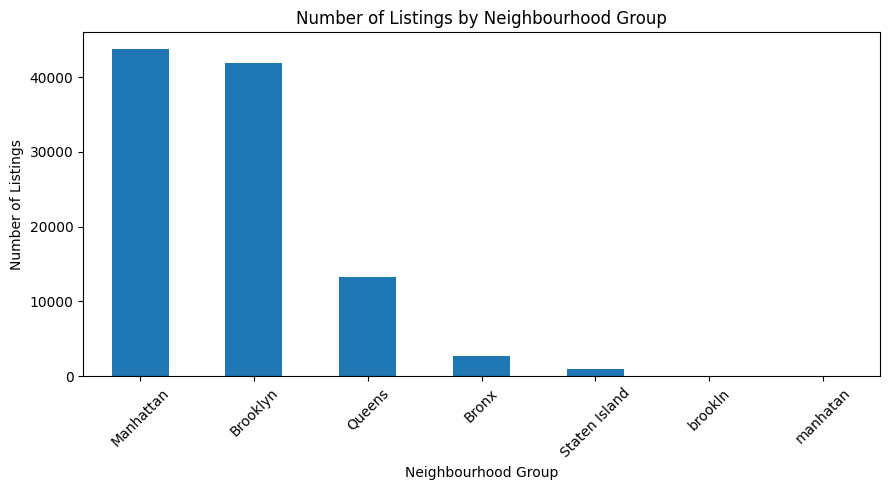

In [6]:
neighbourhood_counts = data['neighbourhood group'].value_counts()
print(neighbourhood_counts)

plt.figure(figsize=(9,5))
neighbourhood_counts.plot(kind='bar')
plt.title('Number of Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Room Type Distribution

room type
Entire home/apt    53701
Private room       46556
Shared room         2226
Hotel room           116
Name: count, dtype: int64


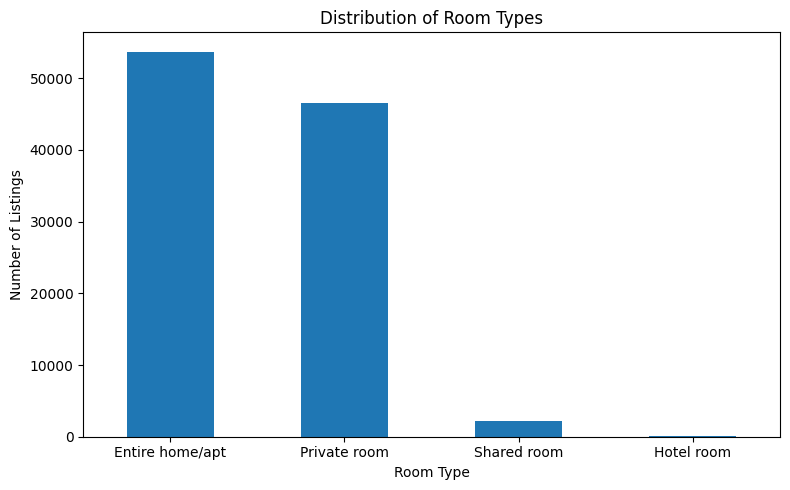

In [7]:
room_counts = data['room type'].value_counts()
print(room_counts)

plt.figure(figsize=(8,5))
room_counts.plot(kind='bar')
plt.title('Distribution of Room Types')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Average Price by Room Type

room type
Hotel room         668.465517
Shared room        634.132101
Entire home/apt    625.082232
Private room       625.007363
Name: price, dtype: float64


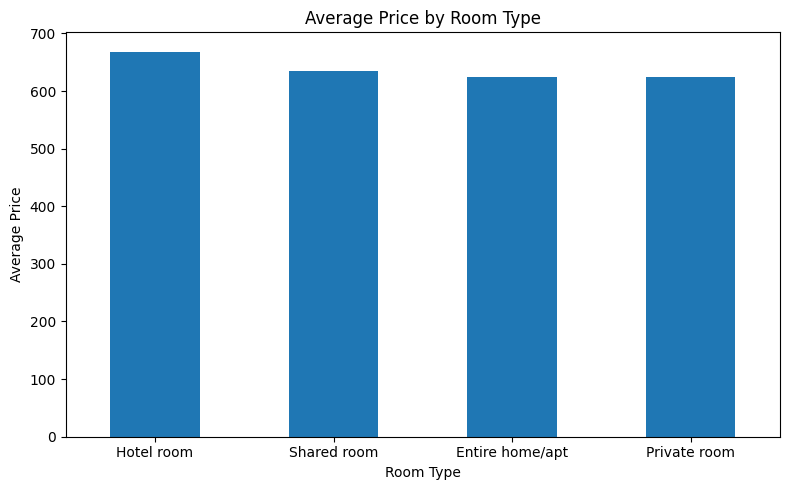

In [8]:
avg_price_room = data.groupby('room type')['price'].mean().sort_values(ascending=False)
print(avg_price_room)

plt.figure(figsize=(8,5))
avg_price_room.plot(kind='bar')
plt.title('Average Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Average Price by Neighbourhood Group

neighbourhood group
Queens           630.207647
Bronx            627.766359
Brooklyn         626.562193
Staten Island    624.490546
Manhattan        622.440227
brookln          580.000000
manhatan         460.000000
Name: price, dtype: float64


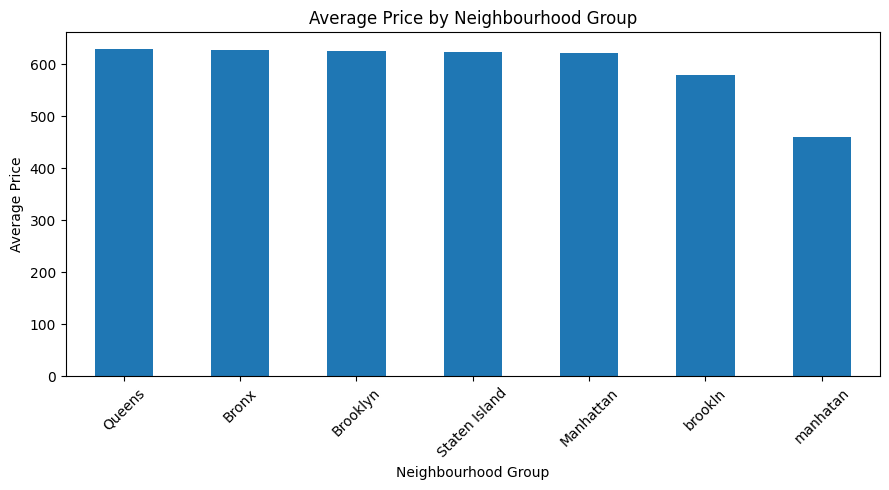

In [9]:
avg_price_neighbourhood = (
    data.groupby('neighbourhood group')['price']
    .mean()
    .sort_values(ascending=False)
)
print(avg_price_neighbourhood)

plt.figure(figsize=(9,5))
avg_price_neighbourhood.plot(kind='bar')
plt.title('Average Price by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Reviews and Availability Analysis

       number of reviews  reviews per month  availability 365
count      102416.000000       86720.000000     102151.000000
mean           27.483743           1.374022        141.133254
std            49.508954           1.746621        135.435024
min             0.000000           0.010000        -10.000000
25%             1.000000           0.220000          3.000000
50%             7.000000           0.740000         96.000000
75%            30.000000           2.000000        269.000000
max          1024.000000          90.000000       3677.000000


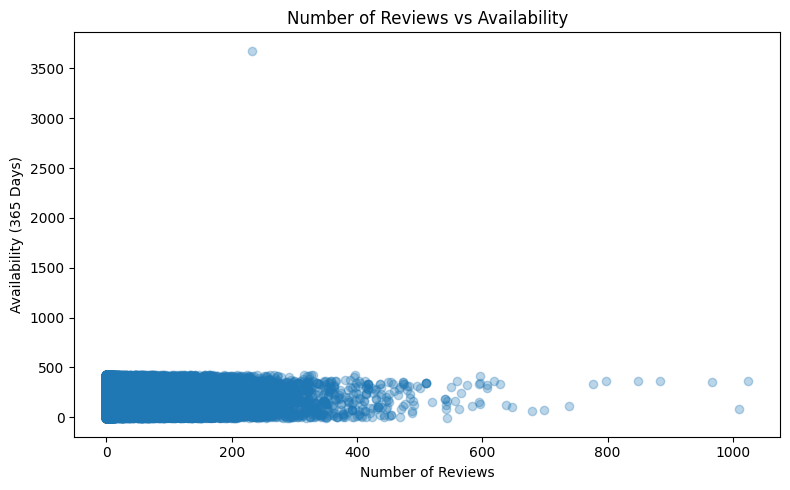

In [10]:
print(data[['number of reviews', 'reviews per month', 'availability 365']].describe())

plt.figure(figsize=(8,5))
plt.scatter(
    data['number of reviews'],
    data['availability 365'],
    alpha=0.3
)
plt.title('Number of Reviews vs Availability')
plt.xlabel('Number of Reviews')
plt.ylabel('Availability (365 Days)')
plt.tight_layout()
plt.show()

## Cancellation Policy Analysis

cancellation_policy
moderate    34343
strict      34106
flexible    34074
Name: count, dtype: int64


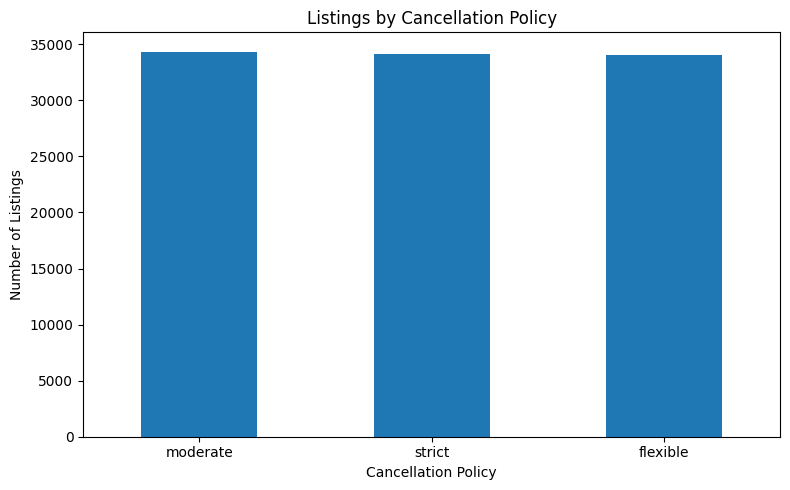

In [11]:
policy_counts = data['cancellation_policy'].value_counts()
print(policy_counts)

plt.figure(figsize=(8,5))
policy_counts.plot(kind='bar')
plt.title('Listings by Cancellation Policy')
plt.xlabel('Cancellation Policy')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Conclusion

The Airbnb Hotel Booking Analysis explores more than 100,000 listing records and examines important factors such as neighbourhood group, room type, price, reviews, availability and cancellation policies.

The analysis demonstrates a complete data analytics workflow including dataset loading, data quality checking, data preparation, aggregation and visualization. The insights can help understand listing distribution and booking-related characteristics across the available Airbnb data.